In [55]:
def get_thresholds(dag: dict, target: str, quantiles: list) -> list: 
    matrix = dag[target]
    N_LAYERS = matrix.shape[0]

    # Create a mask for forward edges (Layer S < Layer R)
    # This ensures we don't include invalid backward connections in our distribution
    s_idx = torch.arange(N_LAYERS).view(-1, 1, 1, 1)
    r_idx = torch.arange(N_LAYERS).view(1, 1, -1, 1)
    mask = (s_idx < r_idx).expand_as(matrix)    
    # Flatten valid weights
    valid_weights = matrix[mask].float()
    valid_weights = torch.abs(valid_weights) 
    valid_weights = valid_weights[valid_weights > 1e-9]

    # Calculate all quantiles at once
    q_tensor = torch.tensor(quantiles, device=valid_weights.device)
    thresholds = torch.quantile(valid_weights, q_tensor)
    
    # Return a dictionary mapping quantile -> threshold
    return dict(zip(quantiles, thresholds.tolist()))

In [93]:
def show_layered_expert_graph(g):
    # 1. Get ONLY the nodes involved in edges
    edge_list = g.get_edgelist()
    if not edge_list:
        print("No edges found to plot!")
        return

    nodes_with_edges = set()
    for s, t in edge_list:
        nodes_with_edges.add(s)
        nodes_with_edges.add(t)
    
    # 2. Create the plotting graph
    G = nx.DiGraph()
    N_EXPERTS = 64
    pos = {}
    labels = {}

    # Multipliers for spacing
    X_SPACING = 250  # Increased horizontal spread
    Y_SPACING = 150  # Vertical distance between layers

    for node_idx in nodes_with_edges:
        layer = node_idx // N_EXPERTS
        expert_idx = node_idx % N_EXPERTS
        
        # Apply spacing multipliers
        pos[node_idx] = (expert_idx * X_SPACING, -layer * Y_SPACING)
        labels[node_idx] = f"M{layer}\nE{expert_idx}"
        G.add_node(node_idx)

    # 3. Add Edges
    weights = []
    for e in g.es:
        G.add_edge(e.source, e.target)

    # 4. Rendering
    # Set the figure size BEFORE calling draw functions
    plt.figure(figsize=(25, 12)) 
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=1400, node_color='white', edgecolors='black', linewidths=1.5)
    
    # Draw Labels
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='bold')
    
    # Draw Edges
    nx.draw_networkx_edges(
        G, pos, 
        edge_color='#444444', 
        alpha=0.7, 
        arrowsize=25, 
        arrowstyle='-|>',
        connectionstyle="arc3,rad=0.1"
    )

    # 5. Scale and Display
    # Dynamically set limits based on nodes present
    all_x = [p[0] for p in pos.values()]
    all_y = [p[1] for p in pos.values()]
    
    plt.xlim(min(all_x) - X_SPACING, max(all_x) + X_SPACING)
    plt.ylim(min(all_y) - Y_SPACING, max(all_y) + Y_SPACING)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show() # Changed from plot.show() to plt.show()

In [17]:
def tresholding_routing_graph(dag: dict, target: str, threshold: float) -> ig.Graph:
    # Get the 4D matrix (Shape: [16, 64, 16, 64])
    matrix = dag[target]
    N_LAYERS, N_EXPERTS = matrix.shape[0], matrix.shape[1]
    N_NODES = N_LAYERS * N_EXPERTS

    # Find where the weights are above the threshold
    s_layers, s_exps, r_layers, r_exps = np.where(matrix > threshold) # This returns 4 arrays (S_layer, S_exp, R_layer, R_exp)

    # Convert those coordinates into Vertex IDs
    senders = s_layers * N_EXPERTS + s_exps
    receivers = r_layers * N_EXPERTS + r_exps

    # Extract the weights for these specific edges
    weights = matrix[s_layers, s_exps, r_layers, r_exps]

    # Build the graph
    g = ig.Graph(directed=True, n=N_NODES)
    
    # zip pairs them up: [(s1, r1), (s2, r2), ...]
    edges = list(zip(senders.tolist(), receivers.tolist()))
    g.add_edges(edges)
    
    # Assign the weights and metadata
    g.es["weight"] = weights.tolist()
    g.vs["layer"] = [v // N_EXPERTS for v in range(N_NODES)]
    g.vs["expert"] = [v % N_EXPERTS for v in range(N_NODES)]

    return g

In [65]:
def max_path_length(g: ig.Graph) -> tuple[list[int], int, int]:
    n = len(g.vs)
    in_degree = g.indegree() 
    dp = [0] * n            # Longest distance from any source to node i
    predecessor = [-1] * n  # predecessors for backtracking
    count = [0] * n         # Number of ways to reach node i with distance dp[i]
    
    # 1. Initialize sources (nodes with no incoming edges)
    sources = [i for i, d in enumerate(in_degree) if d == 0]
    for s in sources:
        count[s] = 1 # Each source starts 1 path of length 0
    
    queue = deque(sources)
    
    while queue:
        curr = queue.popleft()
        
        for neighbor in g.neighbors(curr, mode="out"):
            new_dist = dp[curr] + 1
            
            if new_dist > dp[neighbor]:
                # Found a strictly better path
                dp[neighbor] = new_dist
                predecessor[neighbor] = curr
                count[neighbor] = count[curr] # Reset count to parent's count
            elif new_dist == dp[neighbor]:
                # Found an alternative path of the same max length
                count[neighbor] += count[curr]
            
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
    
    # 3. Identify the Global Maximum
    max_val = max(dp)
    
    # 4. Backtrack to find ONE sample path
    # We pick the FIRST node that reached the max_val to start backtracking
    end_node = dp.index(max_val)
    path = []
    curr_trace = end_node
    while curr_trace != -1:
        path.append(curr_trace)
        curr_trace = predecessor[curr_trace]
    
    # 5. Calculate total paths of length max_val
    # Multiple nodes could end at the same max depth (e.g., different experts in Layer 15)
    total_paths = sum(count[i] for i in range(n) if dp[i] == max_val)
    
    return path[::-1], max_val, total_paths

def path_as_str(path: list) -> str: 
    expert_path = []
    for curr_node in path: 
        layer = curr_node // 64
        expert = curr_node % 64
        expert_path.append(f"M{layer}E{expert}")
    
    return " -> ".join(expert_path)

1: quantile: 0.8999999761581421, threshold: 0.018, max path length: 15, occurences: 929541662709194911935,  path: M0E4 -> M1E7 -> M2E22 -> M3E1 -> M4E1 -> M5E57 -> M6E4 -> M7E19 -> M8E26 -> M9E20 -> M10E28 -> M11E15 -> M12E1 -> M13E10 -> M14E16 -> M15E0.
2: quantile: 0.9131488800048828, threshold: 0.019, max path length: 15, occurences: 91947060640642821173,  path: M0E6 -> M1E7 -> M2E22 -> M3E16 -> M4E52 -> M5E57 -> M6E0 -> M7E14 -> M8E28 -> M9E29 -> M10E63 -> M11E39 -> M12E11 -> M13E8 -> M14E16 -> M15E0.
3: quantile: 0.924568772315979, threshold: 0.021, max path length: 15, occurences: 7514159300112222590,  path: M0E6 -> M1E7 -> M2E22 -> M3E16 -> M4E52 -> M5E57 -> M6E63 -> M7E20 -> M8E13 -> M9E22 -> M10E21 -> M11E43 -> M12E6 -> M13E54 -> M14E9 -> M15E0.
4: quantile: 0.9344871640205383, threshold: 0.023, max path length: 15, occurences: 634429286050160969,  path: M0E6 -> M1E39 -> M2E0 -> M3E49 -> M4E7 -> M5E54 -> M6E6 -> M7E20 -> M8E13 -> M9E22 -> M10E26 -> M11E39 -> M12E11 -> M13E8 ->

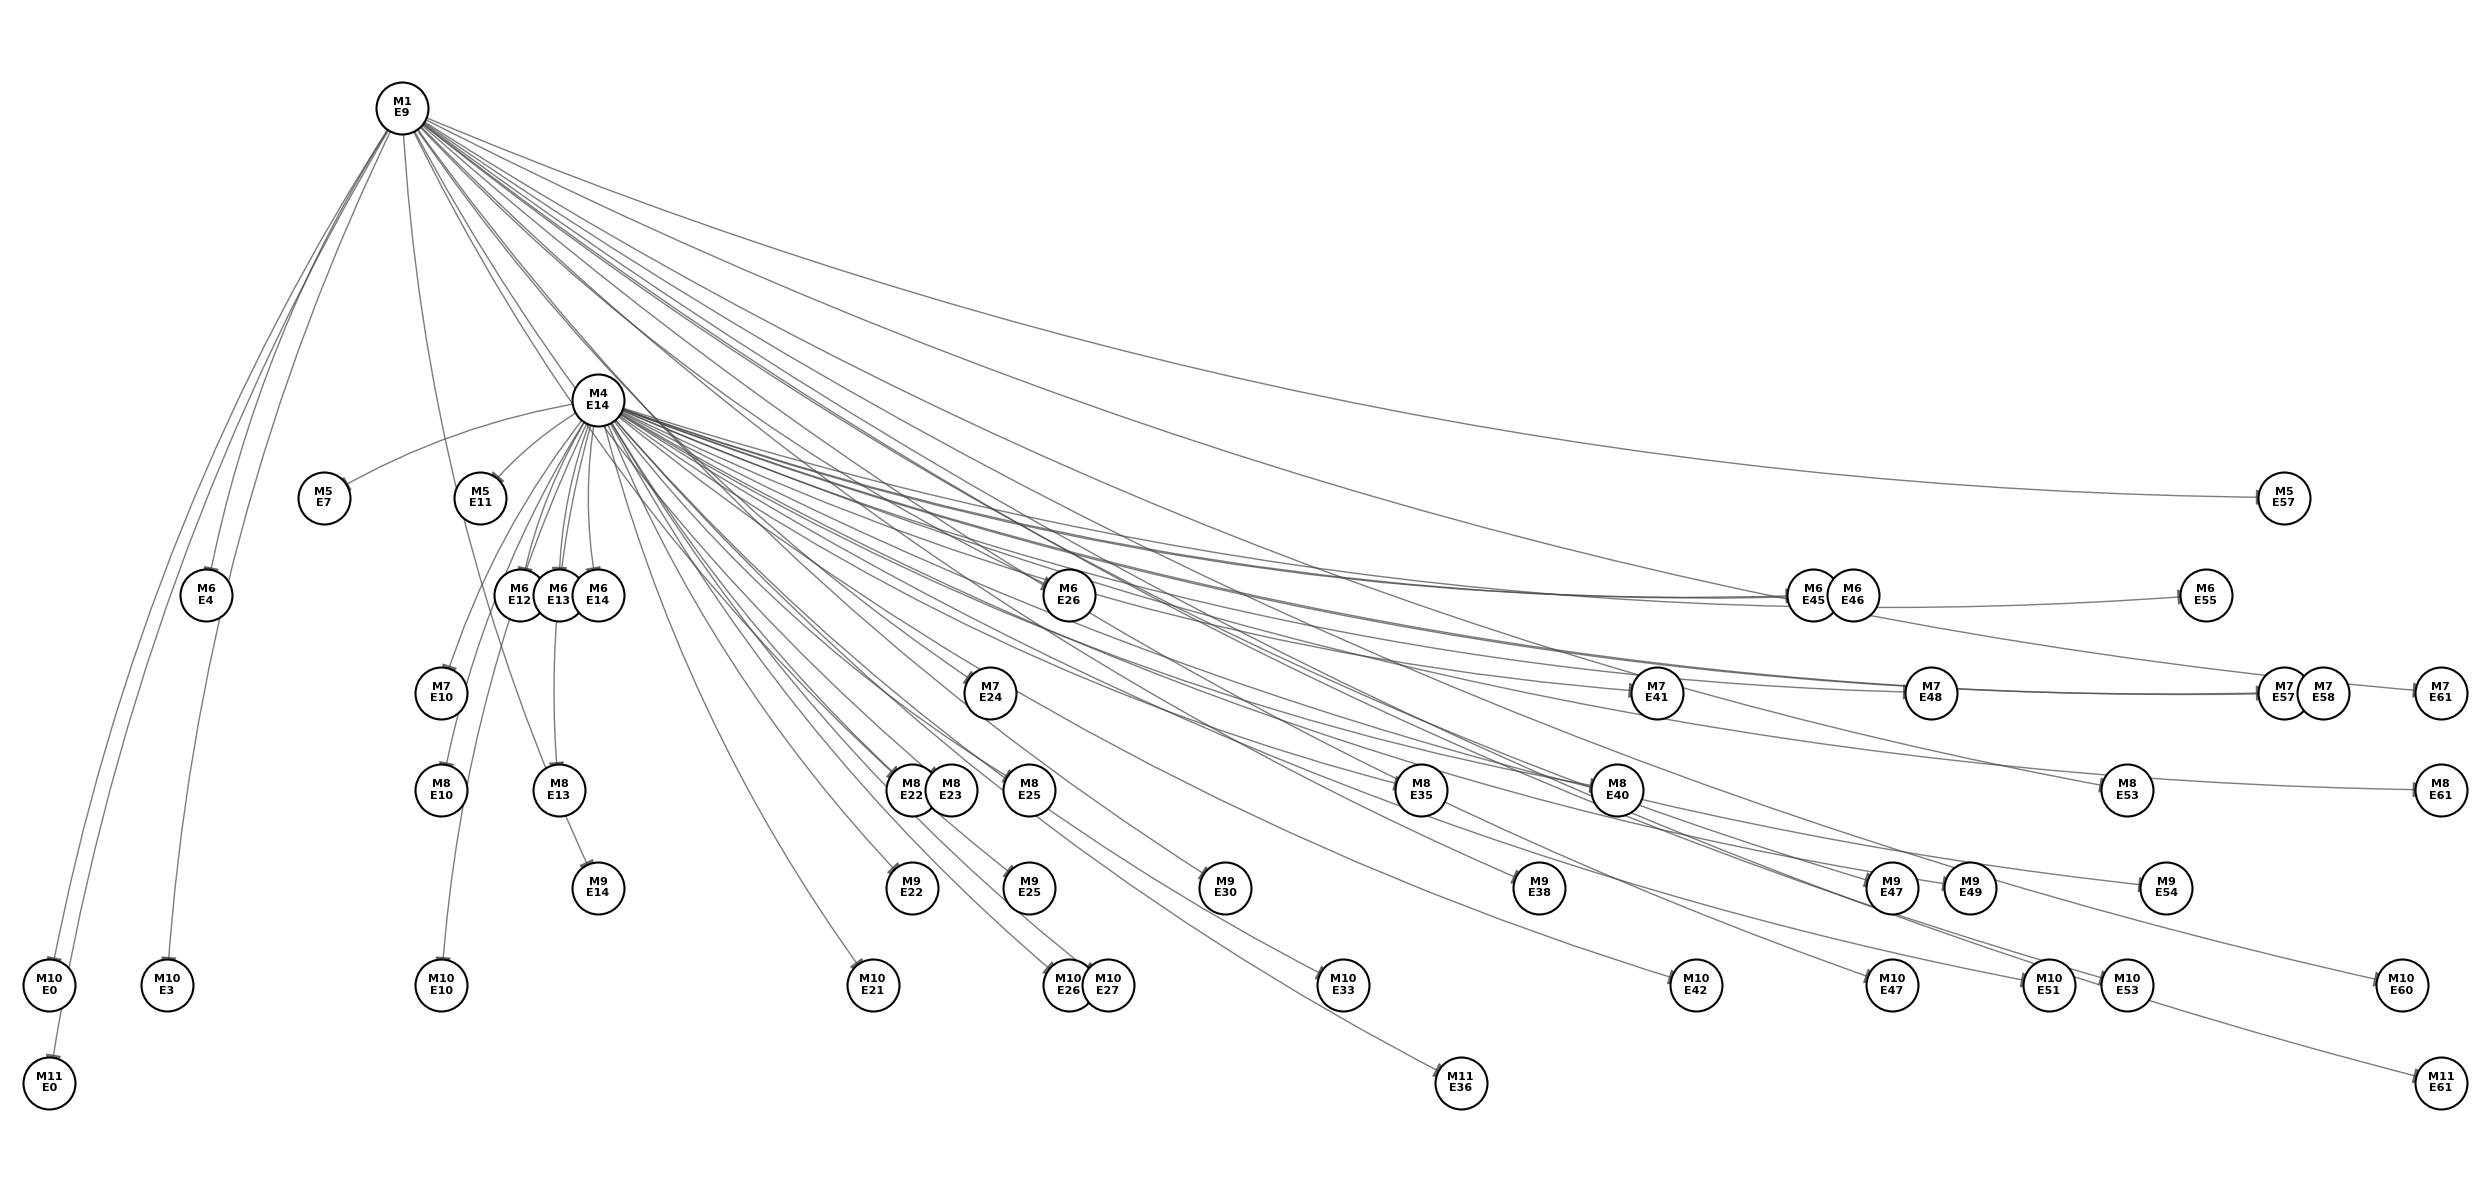

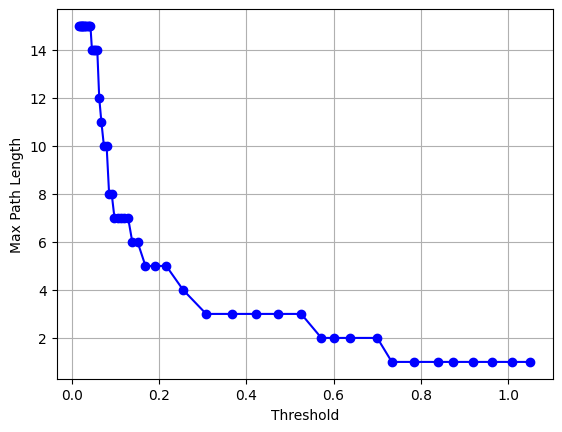

In [ ]:
from __future__ import annotations
from pathlib import Path 

import json, os, sys

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import yaml

import igraph as ig
import leidenalg

from collections import deque 

ROOT = "/scratch/sleonard/routing_decision"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

dataset = "c4"
art_dir = os.path.join(config["result_path"], "circuits")
path = os.path.join(art_dir, f"dag_{dataset}.pt")
dag = torch.load(path, map_location='cpu')


# quantiles = [0.8, 0.9, 0.95, 0.975, 0.98, 0.985, 0.99, 0.995, 0.9975, 0.999, 0.9999]
# quantiles = torch.linspace(0, 1, steps=100).tolist()
quantiles = (1 - torch.logspace(-1, -4, steps=50)).tolist()
target = "VAR"

threshold_map = get_thresholds(dag=dag, target=target, quantiles=quantiles)
i = 0
num_thresholds = len(threshold_map)
x, y = [], []
for q, t in threshold_map.items():
    i += 1
    g = tresholding_routing_graph(dag=dag, target=target, threshold=t)
    path, length, nums = max_path_length(g)
    print(f"{i}: quantile: {q}, threshold: {t:.3f}, max path length: {length}, occurences: {nums},  path: {path_as_str(path)}.")
    x.append(t)
    y.append(length)
    if i == num_thresholds: 
        show_layered_expert_graph(g)
        
    

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.xlabel("Threshold")
plt.ylabel("Max Path Length")
plt.grid(True)
plt.show() 